# ViT Optimizer Dynamics & Representation Geometry Lab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HisameOgasahara/deep-learning-diagnostics-and-improvement/blob/main/colab/vit_optimizer_diagnostics/vit_optimizer_dynamics_geometry_lab.ipynb)

Small ViT 하나를 같은 초기값에서 여러 optimizer로 학습한 뒤, **학습 동역학 → 표현기하 → loss landscape → 함수공간**을 순서대로 비교한다.

기존 진단 코드는 그대로 재사용하고, 최근 논문 조사에서 비어 있던 다섯 축을 뒤에 추가한다.

1. empirical tangent-kernel spectrum / target alignment
2. input-output Jacobian singular spectrum
3. relative sharpness
4. neural-manifold axis geometry / empirical dichotomy capacity
5. parameter-trajectory PCA / path geometry

> 결과 출력은 한 셀에 몰아넣지 않는다. 각 진단량을 자기 셀에서 확인한다.

## 0. 설치와 저장소 준비

In [1]:
!pip -q install datasets prodigyopt tensorboard scikit-learn

%cd /content
!rm -rf deep-learning-diagnostics-and-improvement
!git clone -q https://github.com/HisameOgasahara/deep-learning-diagnostics-and-improvement.git
%cd /content/deep-learning-diagnostics-and-improvement/colab/vit_optimizer_diagnostics

/content
/content/deep-learning-diagnostics-and-improvement/colab/vit_optimizer_diagnostics


In [2]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

from vit_lab_model_optim import SmallViT
from vit_lab_train import train_one_optimizer
from vit_lab_repr import (
    extract_features_and_logits,
    representation_diagnostics,
)
from vit_lab_landscape import (
    run_function_space_comparison,
    run_hessian_diagnostics,
    run_mode_connectivity,
)
from vit_lab_extended import (
    run_jacobian_diagnostics,
    run_manifold_diagnostics,
    run_relative_sharpness_diagnostics,
    run_tangent_kernel_diagnostics,
    run_trajectory_diagnostics,
)

## 1. 실험 설정

기본값은 Colab T4에서 반복 가능한 범위로 둔다. `EPOCHS=50`은 이전 100 epoch 실습보다 짧게 유지하고, 진단 checkpoint만 골라 저장한다.

In [3]:
SEED = 42
EPOCHS = 50
DIAG_EPOCHS = [0, 1, 5, 10, 20, 35, 50]
DYNAMICS_EVERY = 20

TRAIN_SAMPLES = 10_000
VAL_SAMPLES = 2_000
BATCH_SIZE = 256
NUM_WORKERS = 4

OPTIMIZER_NAMES = ["sgd", "adamw", "prodigy", "muon"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = DEVICE.type == "cuda"

ROOT = Path("/content/vit_optimizer_diagnostics_outputs")
CKPT_DIR = ROOT / "checkpoints"
CSV_DIR = ROOT / "csv"
TB_DIR = ROOT / "tensorboard"

for directory in [CKPT_DIR, CSV_DIR, TB_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("device:", DEVICE)
print("outputs:", ROOT)

device: cuda
outputs: /content/vit_optimizer_diagnostics_outputs


In [4]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)

## 2. CIFAR-10 준비

Hugging Face의 CIFAR-10을 한 번 받아 재사용한다. 학습용 augmentation loader와 표현 진단용 deterministic loader를 분리한다.

In [5]:
class HFCifar10Dataset(Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        item = self.dataset[index]
        image = item["img"].convert("RGB")
        label = int(item["label"])
        return self.transform(image), label


mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

In [6]:
raw = load_dataset("uoft-cs/cifar10")

train_split = raw["train"].shuffle(seed=SEED).select(range(TRAIN_SAMPLES))
val_split = raw["test"].shuffle(seed=SEED).select(range(VAL_SAMPLES))

train_dataset = HFCifar10Dataset(train_split, train_transform)
rep_train_dataset = HFCifar10Dataset(train_split, eval_transform)
val_dataset = HFCifar10Dataset(val_split, eval_transform)

loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
    persistent_workers=NUM_WORKERS > 0,
)

train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
rep_train_loader = DataLoader(rep_train_dataset, shuffle=False, **loader_kwargs)
rep_val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)

print(len(train_dataset), len(val_dataset))

README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  120MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.9MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

10000 2000


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 3. 같은 초기값 고정

In [7]:
seed_everything(SEED)
initial_model = SmallViT().to(DEVICE)
initial_state = {
    name: tensor.detach().cpu().clone()
    for name, tensor in initial_model.state_dict().items()
}

init_train_features, _, init_train_labels = extract_features_and_logits(
    initial_model, rep_train_loader, DEVICE
)
init_val_features, init_val_logits, init_val_labels = extract_features_and_logits(
    initial_model, rep_val_loader, DEVICE
)

diagnostic_batch = next(iter(rep_val_loader))

del initial_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 4. Optimizer별 학습

기존 `vit_lab_train.py`의 gradient / update / noise 기록 로직은 수정하지 않는다.

In [8]:
history_frames = []
dynamics_frames = []
noise_frames = []

for optimizer_name in OPTIMIZER_NAMES:
    seed_everything(SEED)

    history_df, dynamics_df, noise_df = train_one_optimizer(
        run_name=optimizer_name,
        initial_state=initial_state,
        train_loader=train_loader,
        val_loader=rep_val_loader,
        device=DEVICE,
        epochs=EPOCHS,
        diag_epochs=DIAG_EPOCHS,
        dynamics_every=DYNAMICS_EVERY,
        ckpt_dir=CKPT_DIR,
        csv_dir=CSV_DIR,
        tb_dir=TB_DIR,
        amp_enabled=AMP_ENABLED,
    )

    history_frames.append(history_df)
    dynamics_frames.append(dynamics_df)
    noise_frames.append(noise_df)

history = pd.concat(history_frames, ignore_index=True)
dynamics = pd.concat(dynamics_frames, ignore_index=True)
gradient_noise = pd.concat(noise_frames, ignore_index=True)

[sgd    ] epoch 01/50 | train 0.2148 | val 0.2360 | 9.0s
[sgd    ] epoch 02/50 | train 0.2774 | val 0.2640 | 6.9s
[sgd    ] epoch 03/50 | train 0.2941 | val 0.3020 | 8.3s
[sgd    ] epoch 04/50 | train 0.3161 | val 0.3500 | 6.8s
[sgd    ] epoch 05/50 | train 0.3425 | val 0.3260 | 8.1s
[sgd    ] epoch 06/50 | train 0.3623 | val 0.3270 | 6.8s
[sgd    ] epoch 07/50 | train 0.3761 | val 0.3705 | 8.1s
[sgd    ] epoch 08/50 | train 0.4045 | val 0.3720 | 7.3s
[sgd    ] epoch 09/50 | train 0.4153 | val 0.3680 | 7.5s
[sgd    ] epoch 10/50 | train 0.4374 | val 0.3780 | 8.0s
[sgd    ] epoch 11/50 | train 0.4163 | val 0.4395 | 6.7s
[sgd    ] epoch 12/50 | train 0.4449 | val 0.3665 | 9.4s
[sgd    ] epoch 13/50 | train 0.4600 | val 0.4405 | 6.7s
[sgd    ] epoch 14/50 | train 0.4756 | val 0.4145 | 8.6s
[sgd    ] epoch 15/50 | train 0.4644 | val 0.4405 | 7.3s
[sgd    ] epoch 16/50 | train 0.4844 | val 0.4555 | 7.2s
[sgd    ] epoch 17/50 | train 0.4815 | val 0.4690 | 8.1s
[sgd    ] epoch 18/50 | train 0

### 4.1 Train / validation curve

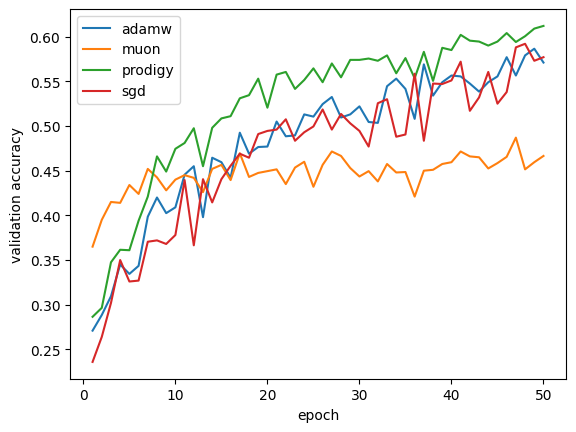

,run,epoch,train_loss,train_accuracy,val_loss,val_accuracy,seconds
49,sgd,50,1.081632,0.6119,1.205854,0.5770,8.083318
99,adamw,50,1.077283,0.6140,1.171259,0.5710,8.208819
149,prodigy,50,0.855245,0.6956,1.137012,0.6120,7.847728
199,muon,50,1.522895,0.4431,1.490599,0.4665,9.730674


In [9]:
for run_name, frame in history.groupby("run"):
    plt.plot(frame["epoch"], frame["val_accuracy"], label=run_name)
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.legend()
plt.show()

history.groupby("run").tail(1)

### 4.2 Gradient norm

In [10]:
gradient_norm = dynamics.groupby(["run", "parameter", "epoch"], as_index=False)["grad_norm"].mean()
gradient_norm.tail(20)

,run,parameter,epoch,grad_norm
780,sgd,patch_embed.proj.weight,31,1.272942
781,sgd,patch_embed.proj.weight,32,1.223377
782,sgd,patch_embed.proj.weight,33,0.949974
783,sgd,patch_embed.proj.weight,34,0.933223
784,sgd,patch_embed.proj.weight,35,1.335400
785,sgd,patch_embed.proj.weight,36,1.067735
786,sgd,patch_embed.proj.weight,37,0.936139
787,sgd,patch_embed.proj.weight,38,1.347543
788,sgd,patch_embed.proj.weight,39,0.777778
789,sgd,patch_embed.proj.weight,40,1.161917


### 4.3 Consecutive gradient cosine

In [11]:
gradient_cosine = dynamics.groupby(["run", "parameter", "epoch"], as_index=False)["grad_cosine_prev"].mean()
gradient_cosine.tail(20)

,run,parameter,epoch,grad_cosine_prev
780,sgd,patch_embed.proj.weight,31,-0.004547
781,sgd,patch_embed.proj.weight,32,-0.089119
782,sgd,patch_embed.proj.weight,33,0.207248
783,sgd,patch_embed.proj.weight,34,-0.136869
784,sgd,patch_embed.proj.weight,35,0.243724
785,sgd,patch_embed.proj.weight,36,0.151529
786,sgd,patch_embed.proj.weight,37,0.106781
787,sgd,patch_embed.proj.weight,38,-0.511209
788,sgd,patch_embed.proj.weight,39,0.012122
789,sgd,patch_embed.proj.weight,40,-0.159388


### 4.4 Update norm

In [12]:
update_norm = dynamics.groupby(["run", "parameter", "epoch"], as_index=False)["update_norm"].mean()
update_norm.tail(20)

,run,parameter,epoch,update_norm
780,sgd,patch_embed.proj.weight,31,0.052990
781,sgd,patch_embed.proj.weight,32,0.058644
782,sgd,patch_embed.proj.weight,33,0.049976
783,sgd,patch_embed.proj.weight,34,0.055743
784,sgd,patch_embed.proj.weight,35,0.062666
785,sgd,patch_embed.proj.weight,36,0.048882
786,sgd,patch_embed.proj.weight,37,0.061322
787,sgd,patch_embed.proj.weight,38,0.056000
788,sgd,patch_embed.proj.weight,39,0.047852
789,sgd,patch_embed.proj.weight,40,0.055373


### 4.5 Update-to-weight ratio

In [13]:
update_to_weight = dynamics.groupby(["run", "parameter", "epoch"], as_index=False)["update_to_weight"].mean()
update_to_weight.tail(20)

,run,parameter,epoch,update_to_weight
780,sgd,patch_embed.proj.weight,31,0.005826
781,sgd,patch_embed.proj.weight,32,0.006429
782,sgd,patch_embed.proj.weight,33,0.005458
783,sgd,patch_embed.proj.weight,34,0.006070
784,sgd,patch_embed.proj.weight,35,0.006806
785,sgd,patch_embed.proj.weight,36,0.005290
786,sgd,patch_embed.proj.weight,37,0.006617
787,sgd,patch_embed.proj.weight,38,0.006027
788,sgd,patch_embed.proj.weight,39,0.005136
789,sgd,patch_embed.proj.weight,40,0.005936


### 4.6 Consecutive update cosine

In [14]:
update_cosine = dynamics.groupby(["run", "parameter", "epoch"], as_index=False)["update_cosine_prev"].mean()
update_cosine.tail(20)

,run,parameter,epoch,update_cosine_prev
780,sgd,patch_embed.proj.weight,31,0.325642
781,sgd,patch_embed.proj.weight,32,-0.113485
782,sgd,patch_embed.proj.weight,33,0.003467
783,sgd,patch_embed.proj.weight,34,-0.213418
784,sgd,patch_embed.proj.weight,35,-0.057530
785,sgd,patch_embed.proj.weight,36,-0.041267
786,sgd,patch_embed.proj.weight,37,-0.092705
787,sgd,patch_embed.proj.weight,38,-0.115641
788,sgd,patch_embed.proj.weight,39,-0.156260
789,sgd,patch_embed.proj.weight,40,-0.059854


### 4.7 Parameter displacement from initialization

In [15]:
parameter_displacement = dynamics.groupby(["run", "parameter", "epoch"], as_index=False)["parameter_displacement"].mean()
parameter_displacement.tail(20)

,run,parameter,epoch,parameter_displacement
780,sgd,patch_embed.proj.weight,31,3.886709
781,sgd,patch_embed.proj.weight,32,3.956170
782,sgd,patch_embed.proj.weight,33,4.023606
783,sgd,patch_embed.proj.weight,34,4.086587
784,sgd,patch_embed.proj.weight,35,4.149967
785,sgd,patch_embed.proj.weight,36,4.222656
786,sgd,patch_embed.proj.weight,37,4.287845
787,sgd,patch_embed.proj.weight,38,4.331007
788,sgd,patch_embed.proj.weight,39,4.385845
789,sgd,patch_embed.proj.weight,40,4.423305


### 4.8 Gradient noise ratio

In [16]:
gradient_noise[["run", "epoch", "parameter", "grad_mean_norm", "grad_variance_trace", "gradient_noise_ratio"]].tail(20)

,run,epoch,parameter,grad_mean_norm,grad_variance_trace,gradient_noise_ratio
780,muon,46,patch_embed.proj.weight,4.754943,20.688421,0.915033
781,muon,46,blocks.0.attn.in_proj_weight,0.922514,0.769771,0.904515
782,muon,46,blocks.3.mlp.fc1.weight,0.021382,0.000527,1.153568
783,muon,46,head.weight,0.527684,0.320886,1.152398
784,muon,47,patch_embed.proj.weight,4.256759,17.149527,0.946442
785,muon,47,blocks.0.attn.in_proj_weight,0.854810,0.704611,0.964297
786,muon,47,blocks.3.mlp.fc1.weight,0.019690,0.000374,0.965229
787,muon,47,head.weight,0.558541,0.244076,0.782377
788,muon,48,patch_embed.proj.weight,7.055945,42.319981,0.850032
789,muon,48,blocks.0.attn.in_proj_weight,1.364476,1.822182,0.978724


## 5. 기존 표현기하 진단 계산

기존 `vit_lab_repr.py`의 covariance spectrum, effective rank, CKA, linear probe, NC geometry를 그대로 호출한다.

In [17]:
representation_df, spectrum_df, class_df = representation_diagnostics(
    optimizer_names=OPTIMIZER_NAMES,
    diag_epochs=DIAG_EPOCHS,
    initial_state=initial_state,
    init_train_features=init_train_features,
    init_train_labels=init_train_labels,
    init_val_features=init_val_features,
    init_val_logits=init_val_logits,
    init_val_labels=init_val_labels,
    rep_train_loader=rep_train_loader,
    rep_val_loader=rep_val_loader,
    ckpt_dir=CKPT_DIR,
    csv_dir=CSV_DIR,
    device=DEVICE,
)

print("representation diagnostics complete")

representation diagnostics complete


### 5.1 Covariance eigenspectrum

In [18]:
spectrum_df.query("layer == 'penultimate' and rank <= 10").tail(40)

,run,epoch,layer,rank,eigenvalue,explained_fraction
3968,muon,10,penultimate,1,53.334524,0.339386
3969,muon,10,penultimate,2,20.522889,0.130594
3970,muon,10,penultimate,3,15.693802,0.099865
3971,muon,10,penultimate,4,15.446126,0.098289
3972,muon,10,penultimate,5,7.877489,0.050127
3973,muon,10,penultimate,6,6.909661,0.043969
3974,muon,10,penultimate,7,5.568692,0.035436
3975,muon,10,penultimate,8,3.687688,0.023466
3976,muon,10,penultimate,9,2.799675,0.017815
3977,muon,10,penultimate,10,2.247815,0.014304


### 5.2 Effective rank

In [19]:
representation_df[["run", "epoch", "layer", "effective_rank"]].tail(25)

,run,epoch,layer,effective_rank
115,muon,5,patch,2.023962
116,muon,5,block2,18.646722
117,muon,5,block4,14.213607
118,muon,5,block6,10.550287
119,muon,5,penultimate,11.733112
120,muon,10,patch,2.254763
121,muon,10,block2,23.067744
122,muon,10,block4,18.260545
123,muon,10,block6,11.802568
124,muon,10,penultimate,13.302616


### 5.3 CKA to initialization

In [20]:
representation_df[["run", "epoch", "layer", "cka_to_init"]].tail(25)

,run,epoch,layer,cka_to_init
115,muon,5,patch,0.997051
116,muon,5,block2,0.312021
117,muon,5,block4,0.310849
118,muon,5,block6,0.263842
119,muon,5,penultimate,0.286599
120,muon,10,patch,0.987385
121,muon,10,block2,0.306895
122,muon,10,block4,0.333445
123,muon,10,block6,0.243699
124,muon,10,penultimate,0.273435


### 5.4 Linear probe accuracy

In [21]:
representation_df[["run", "epoch", "layer", "linear_probe_accuracy"]].tail(25)

,run,epoch,layer,linear_probe_accuracy
115,muon,5,patch,0.2745
116,muon,5,block2,0.4075
117,muon,5,block4,0.4490
118,muon,5,block6,0.4560
119,muon,5,penultimate,0.4515
120,muon,10,patch,0.2735
121,muon,10,block2,0.4285
122,muon,10,block4,0.4605
123,muon,10,block6,0.4680
124,muon,10,penultimate,0.4720


### 5.5 NC1 — within / between class collapse

In [22]:
class_df[["run", "epoch", "nc1_within_between"]]

,run,epoch,nc1_within_between
0,sgd,0,7.797552
1,sgd,1,2.952930
2,sgd,5,3.009135
3,sgd,10,2.838760
4,sgd,20,2.518722
5,sgd,35,2.299630
6,sgd,50,2.120944
7,adamw,0,7.797552
8,adamw,1,2.001671
9,adamw,5,1.912830


### 5.6 NC2 — ETF error

In [23]:
class_df[["run", "epoch", "nc2_etf_error"]]

,run,epoch,nc2_etf_error
0,sgd,0,0.564986
1,sgd,1,0.705255
2,sgd,5,0.610737
3,sgd,10,0.578157
4,sgd,20,0.509150
5,sgd,35,0.492286
6,sgd,50,0.503787
7,adamw,0,0.564986
8,adamw,1,0.760556
9,adamw,5,0.655346


### 5.7 NC3 — classifier / class-center alignment

In [24]:
class_df[["run", "epoch", "nc3_classifier_alignment"]]

,run,epoch,nc3_classifier_alignment
0,sgd,0,-0.022011
1,sgd,1,0.553318
2,sgd,5,0.731966
3,sgd,10,0.804277
4,sgd,20,0.865608
5,sgd,35,0.861415
6,sgd,50,0.868858
7,adamw,0,-0.022011
8,adamw,1,0.474559
9,adamw,5,0.752807


### 5.8 Classification margin

In [25]:
class_df[["run", "epoch", "margin_mean", "margin_median", "margin_p10", "margin_positive_fraction"]]

,run,epoch,margin_mean,margin_median,margin_p10,margin_positive_fraction
0,sgd,0,-0.460655,-0.484216,-0.867064,0.0765
1,sgd,1,-0.602898,-0.468469,-1.697848,0.2360
2,sgd,5,-0.658645,-0.477306,-2.381644,0.3260
3,sgd,10,-0.562910,-0.557292,-2.883749,0.3780
4,sgd,20,-0.088097,-0.018717,-2.247573,0.4945
5,sgd,35,-0.141058,-0.030428,-2.615634,0.4905
6,sgd,50,0.308113,0.394150,-2.390893,0.5770
7,adamw,0,-0.460655,-0.484216,-0.867064,0.0765
8,adamw,1,-0.515195,-0.262782,-1.588677,0.2710
9,adamw,5,-0.485525,-0.365622,-1.797610,0.3345


### 5.9 k-NN purity

In [26]:
class_df[["run", "epoch", "knn_purity"]]

,run,epoch,knn_purity
0,sgd,0,0.19310
1,sgd,1,0.20950
2,sgd,5,0.26675
3,sgd,10,0.30995
4,sgd,20,0.35225
5,sgd,35,0.39605
6,sgd,50,0.42720
7,adamw,0,0.19310
8,adamw,1,0.19955
9,adamw,5,0.26025


### 5.10 Class radius / participation dimension / center correlation

In [27]:
class_df[[
    "run",
    "epoch",
    "mean_class_radius",
    "mean_class_participation_dim",
    "class_center_abs_correlation",
]]

,run,epoch,mean_class_radius,mean_class_participation_dim,class_center_abs_correlation
0,sgd,0,11.081594,3.006149,0.497091
1,sgd,1,8.348785,3.109572,0.662195
2,sgd,5,8.174388,5.611923,0.558016
3,sgd,10,7.188297,7.769643,0.535696
4,sgd,20,5.880250,9.408837,0.472840
5,sgd,35,5.201651,10.840783,0.458144
6,sgd,50,5.336426,11.754010,0.466277
7,adamw,0,11.081594,3.006149,0.497091
8,adamw,1,9.351156,2.203745,0.726009
9,adamw,5,8.984426,3.797300,0.608241


## 6. 기존 loss-landscape 진단

In [29]:
from torch.nn.attention import SDPBackend, sdpa_kernel

with sdpa_kernel(SDPBackend.MATH):
    hessian_df, hessian_summary = run_hessian_diagnostics(
        optimizer_names=OPTIMIZER_NAMES,
        final_epoch=EPOCHS,
        initial_state=initial_state,
        hessian_batch=diagnostic_batch,
        ckpt_dir=CKPT_DIR,
        csv_dir=CSV_DIR,
        device=DEVICE,
        steps=16,
    )

print("Hessian diagnostics complete")

Hessian Lanczos: init
Hessian Lanczos: sgd
Hessian Lanczos: adamw
Hessian Lanczos: prodigy
Hessian Lanczos: muon
Hessian diagnostics complete


### 6.1 Hessian Ritz spectrum

In [30]:
hessian_df[["run", "ritz_rank", "ritz_value"]]

,run,ritz_rank,ritz_value
0,init,1,-52.565142
1,init,2,-41.283399
2,init,3,-33.227354
3,init,4,-30.028336
4,init,5,-23.195484
...,...,...,...
75,muon,12,5757.918873
76,muon,13,6714.951232
77,muon,14,8493.279510
78,muon,15,11175.602455


### 6.2 Min / max curvature and spectral spread

In [31]:
hessian_summary[["run", "min_ritz", "max_ritz", "spectral_spread"]]

,run,min_ritz,max_ritz,spectral_spread
0,adamw,-8.387735,32.725030,41.112765
1,init,-52.565142,59.919338,112.484480
2,muon,-10353.101294,16827.431911,27180.533205
3,prodigy,-36.738806,200.187380,236.926186
4,sgd,-9.211884,29.227933,38.439816


### 6.3 Gradient alignment with top / minimum Hessian directions

In [32]:
hessian_summary[["run", "grad_align_top", "grad_align_min"]]

,run,grad_align_top,grad_align_min
0,adamw,0.474063,0.002652
1,init,0.219229,0.107254
2,muon,0.269515,0.051804
3,prodigy,0.077332,0.051022
4,sgd,0.400363,0.023706


## 7. 기존 함수공간 진단

In [33]:
function_summary, function_pairwise = run_function_space_comparison(
    optimizer_names=OPTIMIZER_NAMES,
    final_epoch=EPOCHS,
    loader=rep_val_loader,
    ckpt_dir=CKPT_DIR,
    csv_dir=CSV_DIR,
    device=DEVICE,
)

print("function-space comparison complete")

function-space comparison complete


### 7.1 Expected calibration error

In [34]:
function_summary

,run,ece
0,sgd,0.051441
1,adamw,0.053564
2,prodigy,0.066769
3,muon,0.027875


### 7.2 Logit distance / prediction disagreement

In [35]:
function_pairwise

,run_a,run_b,logit_mse,prediction_disagreement
0,sgd,adamw,2.229788,0.4250
1,sgd,prodigy,2.542608,0.3830
2,sgd,muon,3.592787,0.5115
3,adamw,prodigy,1.409582,0.3415
4,adamw,muon,2.101427,0.4685
5,prodigy,muon,2.313968,0.4715


## 8. 기존 mode connectivity

In [36]:
connectivity_df, barrier_df = run_mode_connectivity(
    optimizer_names=OPTIMIZER_NAMES,
    final_epoch=EPOCHS,
    loader=rep_val_loader,
    ckpt_dir=CKPT_DIR,
    csv_dir=CSV_DIR,
    device=DEVICE,
    max_samples=1000,
)

print("mode connectivity complete")

Mode connectivity: sgd <-> adamw
Mode connectivity: sgd <-> prodigy
Mode connectivity: sgd <-> muon
Mode connectivity: adamw <-> prodigy
Mode connectivity: adamw <-> muon
Mode connectivity: prodigy <-> muon
mode connectivity complete


### 8.1 Interpolation curve

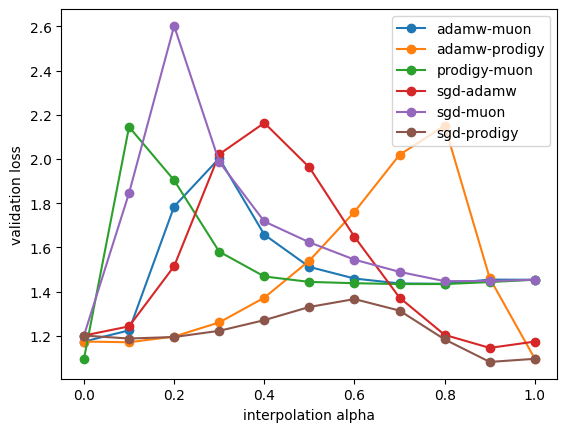

In [37]:
for pair, frame in connectivity_df.groupby(["run_a", "run_b"]):
    plt.plot(frame["alpha"], frame["val_loss"], marker="o", label=f"{pair[0]}-{pair[1]}")
plt.xlabel("interpolation alpha")
plt.ylabel("validation loss")
plt.legend()
plt.show()

### 8.2 Barrier height

In [38]:
barrier_df

,run_a,run_b,barrier_height,midpoint_loss,midpoint_accuracy
0,sgd,adamw,0.962409,1.961685,0.325195
1,sgd,prodigy,0.165099,1.330324,0.533203
2,sgd,muon,1.148666,1.622819,0.401367
3,adamw,prodigy,0.977419,1.539959,0.416992
4,adamw,muon,0.549451,1.511430,0.454102
5,prodigy,muon,0.691683,1.443676,0.469727


# 새로 추가한 5개 진단축

아래부터는 최근 2024–2026 학습동역학·표현기하 논문 조사에서 기존 노트북이 직접 커버하지 못했던 축이다. 계산량이 큰 양은 **무엇을 근사했는지 셀에 명시**한다.

## 9. Empirical tangent kernel — spectrum & target alignment

전체 multiclass NTK를 만드는 대신 Colab T4에서 반복할 수 있도록 **마지막 Transformer block + norm + head에 대한 true-class logit tangent features**를 사용한다. 따라서 결과 이름도 full NTK가 아니라 `partial empirical tangent kernel`로 해석한다.

In [39]:
tangent_summary, tangent_spectrum = run_tangent_kernel_diagnostics(
    optimizer_names=OPTIMIZER_NAMES,
    final_epoch=EPOCHS,
    diagnostic_batch=diagnostic_batch,
    ckpt_dir=CKPT_DIR,
    csv_dir=CSV_DIR,
    device=DEVICE,
    sample_count=24,
)

print("tangent-kernel diagnostics complete")

Tangent kernel: sgd
Tangent kernel: adamw
Tangent kernel: prodigy
Tangent kernel: muon
tangent-kernel diagnostics complete


### 9.1 Kernel-target alignment

In [40]:
tangent_summary[["run", "kernel_target_alignment"]]

,run,kernel_target_alignment
0,sgd,0.848078
1,adamw,0.935624
2,prodigy,0.823384
3,muon,0.861102


### 9.2 Tangent-kernel spectrum / effective rank

In [41]:
display(tangent_summary[["run", "kernel_effective_rank", "kernel_trace", "kernel_top_eigenvalue"]])
display(tangent_spectrum.query("rank <= 10"))

,run,kernel_effective_rank,kernel_trace,kernel_top_eigenvalue
0,sgd,17.554942,2735.693155,439.032428
1,adamw,15.944998,3923.791944,622.944020
2,prodigy,19.287030,7549.995055,818.270440
3,muon,18.851984,4756.702450,584.993546


,run,rank,eigenvalue,explained_fraction
0,sgd,1,439.032428,0.160483
1,sgd,2,322.429591,0.117860
2,sgd,3,246.545745,0.090122
3,sgd,4,214.076770,0.078253
4,sgd,5,167.719199,0.061308
5,sgd,6,148.299009,0.054209
6,sgd,7,143.465115,0.052442
7,sgd,8,119.474301,0.043672
8,sgd,9,106.676784,0.038994
9,sgd,10,91.761643,0.033542


## 10. Input-output Jacobian singular spectrum

Activation covariance는 **표현이 어디에 퍼져 있는가**를 보고, Jacobian은 **입력 방향 변화가 출력에서 얼마나 증폭·감쇠되는가**를 본다. 여기서는 각 이미지에서 `d logits / d input`의 singular values를 계산한다.

In [42]:
jacobian_df, jacobian_summary = run_jacobian_diagnostics(
    optimizer_names=OPTIMIZER_NAMES,
    final_epoch=EPOCHS,
    diagnostic_batch=diagnostic_batch,
    ckpt_dir=CKPT_DIR,
    csv_dir=CSV_DIR,
    device=DEVICE,
    sample_count=8,
)

print("Jacobian diagnostics complete")

Input-output Jacobian: sgd
Input-output Jacobian: adamw
Input-output Jacobian: prodigy
Input-output Jacobian: muon
Jacobian diagnostics complete


### 10.1 Jacobian spectral norm / Frobenius norm / participation rank

In [43]:
jacobian_summary

,run,spectral_norm,frobenius_norm,participation_rank
0,adamw,4.857586,7.130387,3.283292
1,muon,59.892714,67.998513,1.824303
2,prodigy,5.408237,7.775442,3.261586
3,sgd,5.697810,8.586934,3.642714


### 10.2 Mean Jacobian singular-value spectrum

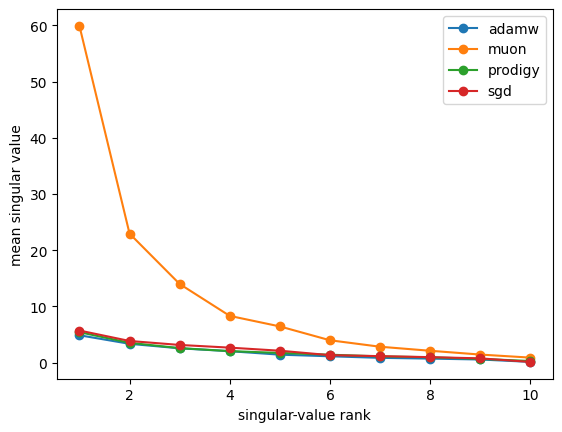

In [44]:
jacobian_mean_spectrum = jacobian_df.groupby(["run", "rank"], as_index=False)["singular_value"].mean()

for run_name, frame in jacobian_mean_spectrum.groupby("run"):
    plt.plot(frame["rank"], frame["singular_value"], marker="o", label=run_name)
plt.xlabel("singular-value rank")
plt.ylabel("mean singular value")
plt.legend()
plt.show()

## 11. Relative sharpness

Raw Hessian eigenvalue는 parameter scaling에 민감하다. 여기서는 final classifier `W`에 대해 cross-entropy Hessian trace와 `||W||_F^2`를 결합한 layerwise relative sharpness를 계산한다.

이 SmallViT에서는 penultimate feature를 `h`, classifier를 `z = W h + b`로 두므로 Hessian trace를 정확히

`E[(1 - ||p||²) ||h||²]`

로 계산할 수 있어 full Hessian을 만들 필요가 없다.

In [45]:
relative_sharpness_df = run_relative_sharpness_diagnostics(
    optimizer_names=OPTIMIZER_NAMES,
    final_epoch=EPOCHS,
    loader=rep_val_loader,
    ckpt_dir=CKPT_DIR,
    csv_dir=CSV_DIR,
    device=DEVICE,
    max_samples=512,
)

relative_sharpness_df

Relative sharpness: sgd
Relative sharpness: adamw
Relative sharpness: prodigy
Relative sharpness: muon


,run,head_weight_norm_sq,head_hessian_trace,relative_sharpness
0,sgd,13.597745,22.437799,305.103474
1,adamw,3.519343,79.987240,281.502525
2,prodigy,2.388153,92.936989,221.947756
3,muon,1.968499,133.946472,263.673537


## 12. Neural-manifold axis geometry / empirical capacity

기존 class radius와 participation dimension에 **center-axis alignment**, **axis-axis alignment**를 추가한다.

`empirical_dichotomy_capacity`는 Chung 계열의 asymptotic replica-theory capacity 공식을 그대로 구현한 값이 아니다. CIFAR-10의 class manifold들에 random binary dichotomy를 부여한 뒤 한 linear hyperplane이 모든 point를 분리할 수 있었던 비율을 재는 **직접적인 empirical separability proxy**다.

In [46]:
manifold_df = run_manifold_diagnostics(
    optimizer_names=OPTIMIZER_NAMES,
    final_epoch=EPOCHS,
    rep_val_loader=rep_val_loader,
    ckpt_dir=CKPT_DIR,
    csv_dir=CSV_DIR,
    device=DEVICE,
    max_samples=1000,
    dichotomy_trials=64,
)

print("manifold diagnostics complete")

Manifold geometry: sgd
Manifold geometry: adamw
Manifold geometry: prodigy
Manifold geometry: muon
manifold diagnostics complete


### 12.1 Radius / dimension

In [47]:
manifold_df[["run", "mean_class_radius", "mean_class_participation_dim"]]

,run,mean_class_radius,mean_class_participation_dim
0,sgd,5.294011,10.993598
1,adamw,8.373756,9.354628
2,prodigy,10.967235,12.478868
3,muon,10.838967,15.075559


### 12.2 Center-axis / axis-axis alignment

In [48]:
manifold_df[["run", "mean_center_axis_alignment", "mean_axis_axis_alignment"]]

,run,mean_center_axis_alignment,mean_axis_axis_alignment
0,sgd,0.571871,0.286842
1,adamw,0.604652,0.303378
2,prodigy,0.561033,0.249702
3,muon,0.568527,0.502265


### 12.3 Empirical random-dichotomy capacity

In [49]:
manifold_df[["run", "empirical_dichotomy_capacity"]]

,run,empirical_dichotomy_capacity
0,sgd,0.031250
1,adamw,0.031250
2,prodigy,0.031250
3,muon,0.015625


## 13. Parameter-trajectory PCA / path geometry

Checkpoint를 각각 따로 보는 대신 `θ_0 → θ_1 → ... → θ_T` 전체를 하나의 경로로 본다. PCA는 실제 이동이 집중된 방향을 보여주고, path/chord ratio는 최종점까지 얼마나 우회했는지를 요약한다.

In [50]:
trajectory_coordinates, trajectory_summary = run_trajectory_diagnostics(
    optimizer_names=OPTIMIZER_NAMES,
    diag_epochs=DIAG_EPOCHS,
    ckpt_dir=CKPT_DIR,
    csv_dir=CSV_DIR,
)

print("trajectory diagnostics complete")

Parameter trajectory: sgd
Parameter trajectory: adamw
Parameter trajectory: prodigy
Parameter trajectory: muon
trajectory diagnostics complete


### 13.1 Trajectory PCA coordinates

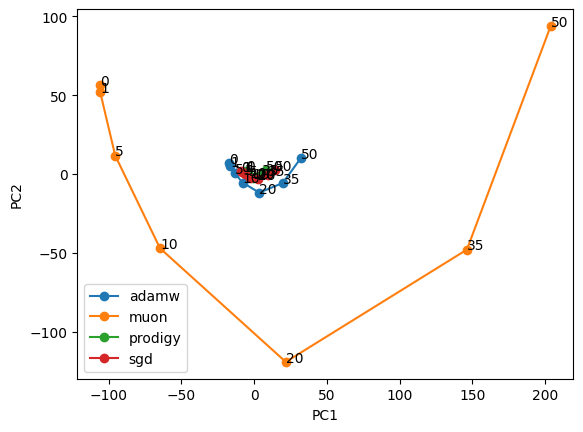

,run,epoch,pc1,pc2
0,sgd,0,-8.751012,2.012291
1,sgd,1,-8.345608,1.584624
2,sgd,5,-6.205987,-0.180214
3,sgd,10,-3.144571,-2.207518
4,sgd,20,2.467386,-3.065016
5,sgd,35,9.333278,-0.593842
6,sgd,50,14.646515,2.449675
7,adamw,0,-17.420994,6.845262
8,adamw,1,-16.599620,5.197085
9,adamw,5,-13.419835,0.670677


In [51]:
for run_name, frame in trajectory_coordinates.groupby("run"):
    plt.plot(frame["pc1"], frame["pc2"], marker="o", label=run_name)
    for _, row in frame.iterrows():
        plt.annotate(str(int(row["epoch"])), (row["pc1"], row["pc2"]))
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

trajectory_coordinates

### 13.2 Explained variance / path geometry

In [52]:
trajectory_summary

,run,pc1_explained,pc2_explained,path_length,chord_length,path_to_chord_ratio,mean_consecutive_step_cosine
0,sgd,0.916411,0.049645,31.333517,23.519884,1.332214,0.522907
1,adamw,0.757361,0.126857,97.788394,50.620861,1.931781,0.159764
2,prodigy,0.787882,0.128281,24.137607,13.612389,1.773209,0.318986
3,muon,0.583342,0.197701,898.373197,326.608649,2.750611,-0.055787


# 14. 새 진단축의 논문 근거

아래는 **노트북에 새로 추가한 부분만** 나중에 검증하기 쉽도록 기법별로 모아 둔 것이다. 기존 진단의 출처 목록과 섞지 않는다.

## 14.1 Empirical tangent kernel / target alignment

**Kumar, Bordelon, Gershman, Pehlevan — _Grokking as the Transition from Lazy to Rich Training Dynamics_, ICLR 2024.**
- 초기 NTK의 top eigendirections와 target의 alignment를 학습 regime 및 grokking과 연결한다.
- 공식 페이지: https://proceedings.iclr.cc/paper_files/paper/2024/hash/63ed15a46a143ff57484b38cd6b85d91-Abstract-Conference.html

**이 노트북의 구현 차이:** full multiclass NTK 대신 T4 비용을 제한하기 위해 마지막 block + norm + head에서 true-class logit gradient로 만든 partial empirical tangent kernel을 사용한다. 따라서 수치 자체를 논문의 full NTK 값과 동일시하면 안 된다.

## 14.2 Input-output Jacobian singular spectrum

**Li, Dai, Qu — _Understanding Generalizability of Diffusion Models Requires Rethinking the Hidden Gaussian Structure_, NeurIPS 2024.**
- denoiser input Jacobian의 leading singular vectors와 singular spectrum을 이용해 입력 방향이 출력에 어떻게 전달되는지 분석하고, leading singular-vector perturbation까지 수행한다.
- 공식 페이지: https://proceedings.neurips.cc/paper_files/paper/2024/hash/69e68611ec4d8c0ae4a4b2bece165f5f-Abstract-Conference.html

**이 노트북의 구현 차이:** diffusion denoiser가 아니라 ViT classifier의 `d logits / d image`를 사용한다. 핵심 수학 구조인 local Jacobian SVD를 ViT에 맞게 옮긴 것이다.

## 14.3 Relative sharpness

**Walter, Adilova, Vreeken, Kamp — _When Flatness Does (Not) Guarantee Adversarial Robustness_, ICLR 2026.**
- raw Hessian trace 대신 layer weight norm과 Hessian trace를 결합한 relative flatness / relative sharpness를 사용하고, penultimate representation과 input-space robustness를 연결한다.
- 공식 페이지: https://proceedings.iclr.cc/paper_files/paper/2026/hash/227277895277e1ec2422ae0c64f29c81-Abstract-Conference.html

**이 노트북의 구현:** `κ_Tr(W) = ||W||_F^2 Tr(H_W)`를 final classifier에서 계산한다. Cross-entropy + linear classifier 구조 덕분에 `Tr(H_W)`는 `E[(1-||p||²)||h||²]`로 정확히 계산한다.

## 14.4 Neural-manifold geometry / capacity

**Chou, Le, Wang, Chung — _Feature Learning beyond the Lazy-Rich Dichotomy: Insights from Representational Geometry_, ICML 2025 Spotlight.**
- class/task manifold의 radius, effective dimension, center/axis geometry, capacity 변화를 학습 중 추적해 representation untangling을 분석한다.
- 공식 페이지: https://proceedings.mlr.press/v267/chou25a.html

**이 노트북의 구현 차이:** radius와 participation dimension, center-axis/axis-axis alignment는 직접 계산하지만, 논문의 replica-theory manifold capacity를 축소 구현하지 않는다. 대신 random class dichotomy의 선형 완전분리 성공률을 `empirical_dichotomy_capacity`로 별도 표기한다.

## 14.5 Parameter trajectory / optimization-path geometry

**Guille-Escuret, Naganuma, Fatras, Mitliagkas — _No Wrong Turns: The Simple Geometry Of Neural Networks Optimization Paths_, ICML 2024.**
- 개별 checkpoint가 아니라 optimization path 위의 gradient geometry를 연구하고 RSI, error bound, 그 비율 γ를 시간축으로 추적한다.
- 공식 페이지: https://proceedings.mlr.press/v235/guille-escuret24a.html

**Song, Ahn, Yun — _Does SGD Really Happen in Tiny Subspaces?_, ICLR 2025.**
- 실제 SGD update와 Hessian dominant subspace의 alignment를 추적하고 projection intervention으로 관찰적 alignment의 기능적 의미를 검증한다.
- 공식 페이지: https://proceedings.iclr.cc/paper_files/paper/2025/hash/1757af1fe1429801bdf3abf5600f8bba-Abstract-Conference.html

**이 노트북의 구현 차이:** 저장된 checkpoint trajectory를 PCA로 투영하고 path length, endpoint chord, path/chord ratio, consecutive-step cosine을 계산한다. `No Wrong Turns`의 RSI/EB/γ를 그대로 재현하는 셀은 아니므로 결과 이름을 그 용어로 표기하지 않는다.

---

## 해석 원칙

- `covariance spectrum`과 `Jacobian spectrum`을 같은 것으로 해석하지 않는다.
- `partial tangent kernel`을 full NTK라고 부르지 않는다.
- `empirical_dichotomy_capacity`를 이론적 manifold capacity와 동일시하지 않는다.
- relative sharpness는 raw Hessian max eigenvalue를 대체하는 값이 아니라 **parameter scaling을 통제하는 보완 진단**으로 같이 본다.
- trajectory PCA는 많이 이동한 방향을 보여주고 Hessian eigenspace는 많이 휘는 방향을 보여주므로 둘을 구분한다.

# 15. 출력 파일

모든 수치는 `/content/vit_optimizer_diagnostics_outputs/csv`에 CSV로 남는다. 새 파일은 다음과 같다.

- `tangent_kernel_summary.csv` / `tangent_kernel_spectrum.csv`
- `jacobian_summary.csv` / `jacobian_spectrum.csv`
- `relative_sharpness.csv`
- `manifold_geometry_extended.csv`
- `trajectory_pca.csv` / `trajectory_path_summary.csv`